<a href="https://colab.research.google.com/github/parameshbadineni/DecisionTree/blob/develop/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training GAN...


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


Epoch [1/30] D_loss: 0.8038 G_loss: 2.1946
Epoch [2/30] D_loss: 0.4471 G_loss: 1.1426
Epoch [3/30] D_loss: 0.4602 G_loss: 1.5820
Epoch [4/30] D_loss: 0.4873 G_loss: 1.2795
Epoch [5/30] D_loss: 0.4897 G_loss: 0.9557
Epoch [6/30] D_loss: 0.5322 G_loss: 1.3947
Epoch [7/30] D_loss: 0.6291 G_loss: 0.4992
Epoch [8/30] D_loss: 0.5816 G_loss: 1.5824
Epoch [9/30] D_loss: 0.5981 G_loss: 1.0012
Epoch [10/30] D_loss: 0.7099 G_loss: 1.7169
Epoch [11/30] D_loss: 0.5475 G_loss: 0.9801
Epoch [12/30] D_loss: 0.5961 G_loss: 1.0118
Epoch [13/30] D_loss: 0.5852 G_loss: 1.4806
Epoch [14/30] D_loss: 0.6384 G_loss: 0.6784
Epoch [15/30] D_loss: 0.6659 G_loss: 0.5820
Epoch [16/30] D_loss: 0.5279 G_loss: 1.2474
Epoch [17/30] D_loss: 0.5524 G_loss: 1.0275
Epoch [18/30] D_loss: 0.5990 G_loss: 0.6027
Epoch [19/30] D_loss: 0.5840 G_loss: 1.0527
Epoch [20/30] D_loss: 0.5604 G_loss: 0.9401
Epoch [21/30] D_loss: 0.6030 G_loss: 0.8011
Epoch [22/30] D_loss: 0.5831 G_loss: 0.8545
Epoch [23/30] D_loss: 0.5384 G_loss: 1.07

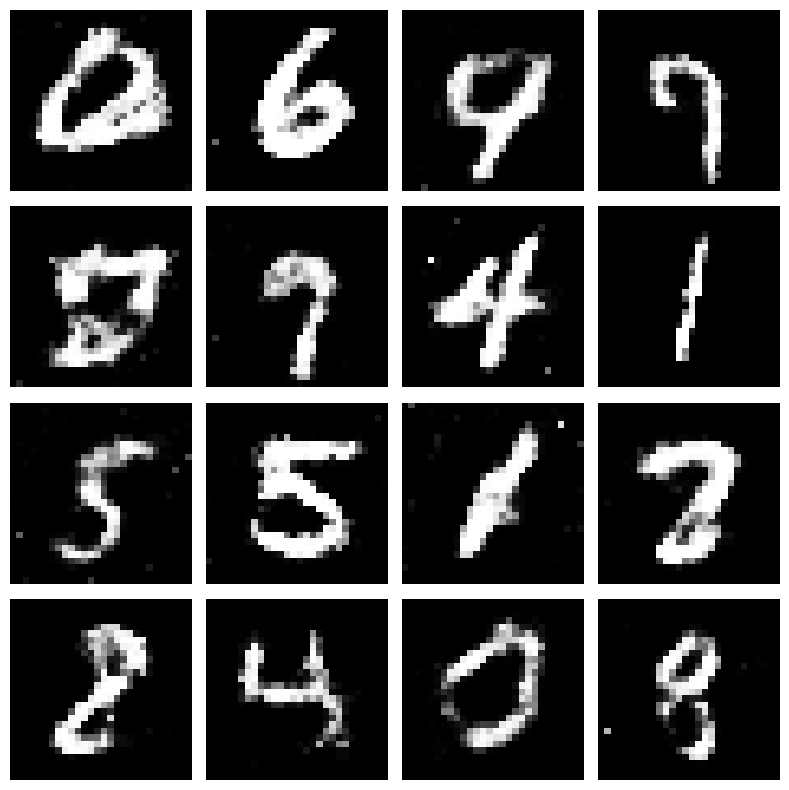

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Generator network
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_shape=(1, 28, 28)):
        super(Generator, self).__init__()
        self.img_shape = img_shape

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, int(torch.prod(torch.tensor(img_shape)))),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *self.img_shape)
        return img

# Discriminator network
class Discriminator(nn.Module):
    def __init__(self, img_shape=(1, 28, 28)):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(int(torch.prod(torch.tensor(img_shape))), 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

# Training function
def train_gan(epochs=50, batch_size=64, latent_dim=100, lr=0.0002):
    # Load MNIST dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize models
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator = Generator(latent_dim).to(device)
    discriminator = Discriminator().to(device)

    # Loss and optimizers
    criterion = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    # Training loop
    for epoch in range(epochs):
        for i, (real_imgs, _) in enumerate(dataloader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)

            # Labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            optimizer_D.zero_grad()
            real_loss = criterion(discriminator(real_imgs), real_labels)

            z = torch.randn(batch_size, latent_dim).to(device)
            fake_imgs = generator(z)
            fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, latent_dim).to(device)
            gen_imgs = generator(z)
            g_loss = criterion(discriminator(gen_imgs), real_labels)
            g_loss.backward()
            optimizer_G.step()

        print(f"Epoch [{epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

    return generator, discriminator

# Generate and display images
def generate_images(generator, num_images=16, latent_dim=100):
    device = next(generator.parameters()).device
    z = torch.randn(num_images, latent_dim).to(device)

    with torch.no_grad():
        generated_imgs = generator(z).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Run training
if __name__ == "__main__":
    print("Training GAN...")
    generator, discriminator = train_gan(epochs=30, batch_size=64)

    print("\nGenerating images...")
    generate_images(generator)